### Machine Project 2 - Color Transformations
**IMAGPRO - S11**

*Group Members:*
- Agustines, Alfred Bastin
- De Leon, Allan David
- Depasucat, Michael Angelo
- Marquez, Vincent Alvin
- Padilla, Kai Hiori

---

#### **Import Dependencies and Configurations**


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from glob import glob

# ==============================
# Directory Configuration (Relative Paths)
# ==============================
# Each action item writes to its own folder so outputs can be compared side-by-side.

DATASET_DIR      = 'dataset/flowers_dataset'
TRANSFORMED_DIR  = 'A1_transformed'           # Item 1 output
CLEANED_DIR      = 'A2_cleaned'               # Item 2 output
ENHANCED_EXP_DIR = 'A3_enhanced/exposure'     # Item 3 output — gamma correction only
ENHANCED_SAT_DIR = 'A3_enhanced/saturation'   # Item 3 output — gamma + saturation (final)
BASE_AUG_DIR     = 'A4_augmented'             # Item 4 output

for d in [TRANSFORMED_DIR, CLEANED_DIR, ENHANCED_EXP_DIR, ENHANCED_SAT_DIR]:
    os.makedirs(d, exist_ok=True)

aug_subfolders = ['patch', 'shift', 'rotate', 'flip', 'sat_increase', 'sat_decrease']
for folder in aug_subfolders:
    os.makedirs(os.path.join(BASE_AUG_DIR, folder), exist_ok=True)

# ==============================
# Augmentation Parameters (from MP1)
# ==============================
P_SIZE      = (25, 25)        # Black patch size (width, height)
S_TX, S_TY  = 20, 20          # Shift offsets
ROT_A       = 30              # Rotation angle (degrees)
FLIP_A      = 'horizontal'    # Flip mode

# ==============================
# Enhancement Parameters (Manual Selection)
# ==============================
# After running the "Inspect Dataset Stats" cell, set these to the
# filenames of the brightest and most saturated images in A2_cleaned/
BRIGHTEST_IMAGE      = '0020.jpg'   # <-- update after inspecting stats
MOST_SATURATED_IMAGE = '0003.jpg'   # <-- update after inspecting stats

# Saturation augmentation scale factors
SAT_INCREASE = 1.5   # 50% saturation boost
SAT_DECREASE = 0.5   # 50% saturation reduction

#### **Action Item 1: Information Extraction**

Given the image dataset:
- Reshape the images to `(100, 100, 3)`
- Save the transformed images as JPEG files in a separate directory
- Create a histogram for the following channels: **Reds, Greens, Blues, Hues, Saturations, Intensities**

In [10]:
# Collect all images from the dataset folder
image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.jfif']
image_files = []
for ext in image_extensions:
    image_files.extend(glob(os.path.join(DATASET_DIR, ext)))
image_files = sorted(image_files)

formatted_images = []
failed_images = []

for fpath in image_files:
    img = cv2.imread(fpath)
    if img is not None:
        resized = cv2.resize(img, (100, 100))    # Reshape to (100, 100, 3)
        fname = os.path.splitext(os.path.basename(fpath))[0] + '.jpg'
        cv2.imwrite(os.path.join(TRANSFORMED_DIR, fname), resized)
        formatted_images.append(resized)
    else:
        failed_images.append(os.path.basename(fpath))

print(f"Successfully formatted {len(formatted_images)} images → saved to '{TRANSFORMED_DIR}'")
if failed_images:
    print(f"Failed to read {len(failed_images)} images: {failed_images}")

Successfully formatted 10 images → saved to 'A1_transformed'


#### **Action Item 1 (continued): Channel Histograms**

Aggregate histograms are computed across all images for the six channels:
- **RGB space:** Red, Green, Blue
- **HSV space:** Hue, Saturation, Value (Intensity)

> OpenCV stores Hue in the range `[0, 179]` — multiply by 2 for the standard `[0°, 360°]` scale.

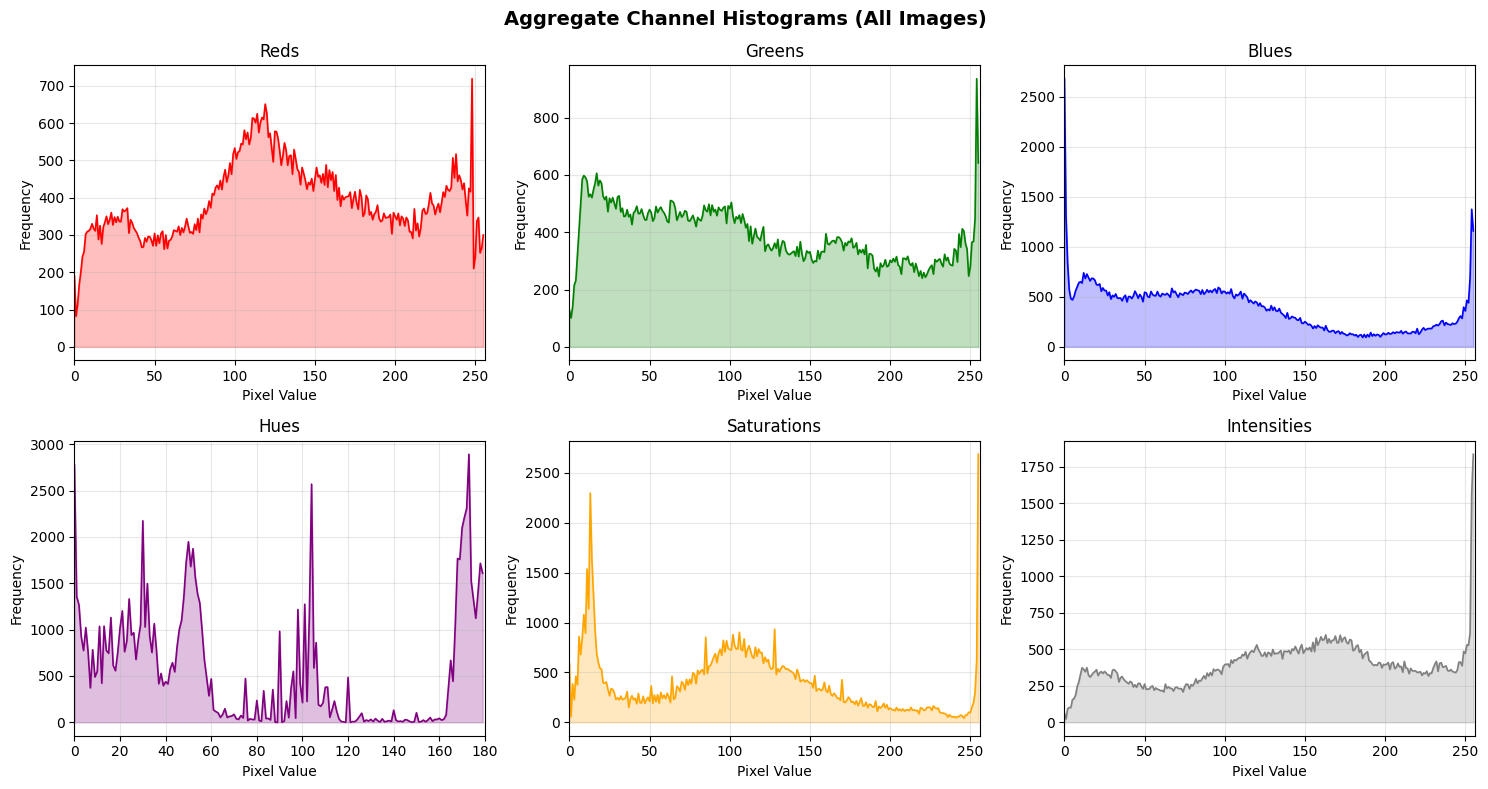

Note: Hue values in OpenCV are halved (0–179); multiply by 2 for standard 0–360° scale.


In [11]:
# Build aggregate histograms across all formatted images
# RGB: channel index 2=R, 1=G, 0=B  (OpenCV uses BGR order)
# HSV: H=Hue (0-179), S=Saturation (0-255), V=Value/Intensity (0-255)

agg = {ch: np.zeros(256 if ch != 'H' else 180) for ch in ['R', 'G', 'B', 'H', 'S', 'V']}

for img in formatted_images:
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    agg['R'] += cv2.calcHist([img], [2], None, [256], [0, 256]).flatten()
    agg['G'] += cv2.calcHist([img], [1], None, [256], [0, 256]).flatten()
    agg['B'] += cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
    agg['H'] += cv2.calcHist([hsv],  [0], None, [180], [0, 180]).flatten()
    agg['S'] += cv2.calcHist([hsv],  [1], None, [256], [0, 256]).flatten()
    agg['V'] += cv2.calcHist([hsv],  [2], None, [256], [0, 256]).flatten()

# Plot all six histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Aggregate Channel Histograms (All Images)', fontsize=14, fontweight='bold')

channel_cfg = [
    ('R', 'Reds',        'red'),
    ('G', 'Greens',      'green'),
    ('B', 'Blues',       'blue'),
    ('H', 'Hues',        'purple'),
    ('S', 'Saturations', 'orange'),
    ('V', 'Intensities', 'gray'),
]

for ax, (key, title, color) in zip(axes.flatten(), channel_cfg):
    hist = agg[key]
    ax.plot(hist, color=color, linewidth=1.2)
    ax.fill_between(range(len(hist)), hist, alpha=0.25, color=color)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Pixel Value')
    ax.set_ylabel('Frequency')
    ax.set_xlim([0, len(hist)])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Note: Hue values in OpenCV are halved (0–179); multiply by 2 for standard 0–360° scale.")

#### **Guide Questions — Action Item 1:**

1. In the RGB space, which channel is most likely to be observed for all images?

2. In the HSV space, which top three hues are most likely to be observed for all images?

#### **Action Item 2: Data Cleaning**

Develop a function that attains the following:
- Remove all images that are taken **during the night**
- Remove all images that are **not pink flowers**

In [12]:
# ==============================
# Night Detection
# ==============================
# Strategy: images taken at night have a very low overall brightness.
# We measure the mean Value (V) channel in HSV space.
# Threshold: mean V < 85 (out of 255) → classified as a night image.
NIGHT_V_THRESHOLD = 85

def is_night_image(img_bgr, threshold=NIGHT_V_THRESHOLD):
    """Return True if the image is likely taken at night (low mean brightness)."""
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    return float(np.mean(hsv[:, :, 2])) < threshold

# ==============================
# Pink Flower Detection
# ==============================
# Strategy: pink/magenta hues in OpenCV HSV occupy H ∈ [140, 175]
# (equivalent to ~280–350° on the standard 0–360° scale).
# We also require moderate saturation (S > 40) to exclude near-white pixels.
# If the fraction of qualifying "pink" pixels exceeds 5% of the image area,
# the image is classified as containing a pink flower.
HUE_LOW, HUE_HIGH = 140, 175
SAT_MIN           = 40
PINK_RATIO_MIN    = 0.05

def is_pink_flower(img_bgr, hue_low=HUE_LOW, hue_high=HUE_HIGH,
                   sat_min=SAT_MIN, min_ratio=PINK_RATIO_MIN):
    """Return True if the image contains a sufficient proportion of pink pixels."""
    hsv   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([hue_low, sat_min, 30])
    upper = np.array([hue_high, 255, 255])
    mask  = cv2.inRange(hsv, lower, upper)
    ratio = np.sum(mask > 0) / (img_bgr.shape[0] * img_bgr.shape[1])
    return ratio >= min_ratio

# ==============================
# Apply Cleaning to Transformed Dataset
# ==============================
transformed_files = sorted(glob(os.path.join(TRANSFORMED_DIR, '*.jpg')))
kept, removed_night, removed_non_pink = [], [], []

for fpath in transformed_files:
    img   = cv2.imread(fpath)
    fname = os.path.basename(fpath)

    if is_night_image(img):
        removed_night.append(fname)
        continue

    if not is_pink_flower(img):
        removed_non_pink.append(fname)
        continue

    cv2.imwrite(os.path.join(CLEANED_DIR, fname), img)
    kept.append(fname)

print(f"Kept               : {len(kept)} → {kept}")
print(f"Removed (night)    : {len(removed_night)} → {removed_night}")
print(f"Removed (non-pink) : {len(removed_non_pink)} → {removed_non_pink}")

Kept               : 5 → ['0002.jpg', '0003.jpg', '0008.jpg', '0010.jpg', '0020.jpg']
Removed (night)    : 2 → ['0001.jpg', '0009.jpg']
Removed (non-pink) : 3 → ['0007.jpg', '0011.jpg', '0030.jpg']


#### **Guide Questions — Action Item 2:**

1. What mathematical or statistical bases have you considered when developing your function?

2. What are the challenges in re-orienting the images in this action item?

3. What can you suggest for automating such a task?

#### **Action Item 3: Data Enhancement**

From the cleaned dataset, develop and apply a function that:
- **Adjusts the exposure** of the images based on the brightest image *(Hint: Gamma Correction)*
- **Adjusts the saturation** of the images to match the saturation of the most saturated image *(Hint: Histogram Equalization + Channel Arithmetic)*

In [13]:
# ==============================
# Inspect Dataset Stats for Manual Selection
# ==============================
# Run this cell to identify which cleaned image is the brightest and
# which is the most saturated. Then update BRIGHTEST_IMAGE and
# MOST_SATURATED_IMAGE in the config cell (top of notebook) if needed.

cleaned_files = sorted(glob(os.path.join(CLEANED_DIR, '*.jpg')))

print(f"{'Filename':<15} {'Mean Brightness (V)':<25} {'Mean Saturation (S)'}")
print("-" * 60)

stats = []
for fpath in cleaned_files:
    img   = cv2.imread(fpath)
    hsv   = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mean_v = float(np.mean(hsv[:, :, 2]))
    mean_s = float(np.mean(hsv[:, :, 1]))
    stats.append((os.path.basename(fpath), mean_v, mean_s))
    print(f"{os.path.basename(fpath):<15} {mean_v:<25.2f} {mean_s:.2f}")

brightest = max(stats, key=lambda x: x[1])
most_sat  = max(stats, key=lambda x: x[2])
print(f"\n→ Brightest image     : {brightest[0]}  (V = {brightest[1]:.2f})")
print(f"→ Most saturated image: {most_sat[0]}  (S = {most_sat[2]:.2f})")
print("\nUpdate BRIGHTEST_IMAGE / MOST_SATURATED_IMAGE in the config cell if needed, then re-run.")

Filename        Mean Brightness (V)       Mean Saturation (S)
------------------------------------------------------------
0002.jpg        153.34                    56.53
0003.jpg        178.13                    138.36
0008.jpg        144.00                    105.90
0010.jpg        135.88                    92.85
0020.jpg        175.76                    61.63

→ Brightest image     : 0003.jpg  (V = 178.13)
→ Most saturated image: 0003.jpg  (S = 138.36)

Update BRIGHTEST_IMAGE / MOST_SATURATED_IMAGE in the config cell if needed, then re-run.


In [14]:
# ==============================
# Gamma Correction (Exposure Adjustment)
# ==============================
# For each image, we compute the gamma value that maps its current mean brightness
# to the target (brightest image's) mean brightness.
#
# Formula: gamma = log(current_V / 255) / log(target_V / 255)
#   gamma < 1 → brightens the image
#   gamma > 1 → darkens the image

def apply_gamma(img_bgr, gamma):
    """Apply gamma correction to adjust image exposure via a LUT."""
    inv_gamma = 1.0 / gamma
    lut = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)], dtype=np.uint8)
    return cv2.LUT(img_bgr, lut)

# ==============================
# Saturation Adjustment (Histogram Equalization + Channel Arithmetic)
# ==============================
# Step 1: Equalize the S channel histogram to redistribute the distribution.
# Step 2: Scale the equalized S channel so its mean matches the target mean saturation.

def adjust_saturation_to_target(img_bgr, target_mean_s):
    """Equalize S channel then scale via channel arithmetic to match target saturation."""
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    h, s, v = cv2.split(hsv)

    # Histogram equalization on S channel
    s_eq = cv2.equalizeHist(s.astype(np.uint8)).astype(np.float32)

    # Channel arithmetic: scale equalized S to match target mean
    current_mean = float(np.mean(s_eq))
    if current_mean > 0:
        s_scaled = np.clip(s_eq * (target_mean_s / current_mean), 0, 255)
    else:
        s_scaled = s_eq

    result = cv2.merge([h, s_scaled, v]).astype(np.uint8)
    return cv2.cvtColor(result, cv2.COLOR_HSV2BGR)

# ==============================
# Apply Enhancements to All Cleaned Images
# ==============================
# Outputs are saved to two separate folders so each step can be compared:
#   enhanced_dataset/exposure/   ← gamma correction only
#   enhanced_dataset/saturation/ ← gamma + saturation adjustment (final)

ref_bright = cv2.imread(os.path.join(CLEANED_DIR, BRIGHTEST_IMAGE))
ref_sat    = cv2.imread(os.path.join(CLEANED_DIR, MOST_SATURATED_IMAGE))

if ref_bright is None or ref_sat is None:
    print("ERROR: Could not load representative image(s). Check filenames in the config cell.")
else:
    target_v = float(np.mean(cv2.cvtColor(ref_bright, cv2.COLOR_BGR2HSV)[:, :, 2]))
    target_s = float(np.mean(cv2.cvtColor(ref_sat,    cv2.COLOR_BGR2HSV)[:, :, 1]))
    print(f"Target brightness (V) from '{BRIGHTEST_IMAGE}'     : {target_v:.2f}")
    print(f"Target saturation (S) from '{MOST_SATURATED_IMAGE}': {target_s:.2f}\n")

    cleaned_files = sorted(glob(os.path.join(CLEANED_DIR, '*.jpg')))
    for fpath in cleaned_files:
        img   = cv2.imread(fpath)
        fname = os.path.basename(fpath)

        # Compute per-image gamma based on its current brightness
        cur_v = float(np.mean(cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[:, :, 2]))
        eps   = 1e-7
        if cur_v > 0 and target_v > 0:
            gamma = np.log(cur_v / 255.0 + eps) / np.log(target_v / 255.0 + eps)
            gamma = float(np.clip(gamma, 0.1, 5.0))
        else:
            gamma = 1.0

        # Step 1: gamma correction → save to exposure/
        img_exposed = apply_gamma(img, gamma)
        cv2.imwrite(os.path.join(ENHANCED_EXP_DIR, fname), img_exposed)

        # Step 2: saturation adjustment on top → save to saturation/
        img_enhanced = adjust_saturation_to_target(img_exposed, target_s)
        cv2.imwrite(os.path.join(ENHANCED_SAT_DIR, fname), img_enhanced)

        print(f"  {fname}: gamma={gamma:.3f}")

    print(f"\nStep 1 (exposure only) → '{ENHANCED_EXP_DIR}'")
    print(f"Step 2 (+ saturation)  → '{ENHANCED_SAT_DIR}'")

Target brightness (V) from '0020.jpg'     : 175.76
Target saturation (S) from '0003.jpg': 138.36

  0002.jpg: gamma=1.367
  0003.jpg: gamma=0.964
  0008.jpg: gamma=1.536
  0010.jpg: gamma=1.691
  0020.jpg: gamma=1.000

Step 1 (exposure only) → 'A3_enhanced/exposure'
Step 2 (+ saturation)  → 'A3_enhanced/saturation'


#### **Action Item 4: Modified Data Augmentation**

Reusing the geometric augmentation functions from MP1, with the addition of:
- **Saturation Increase** — multiply the S channel by `1.5×`
- **Saturation Decrease** — multiply the S channel by `0.5×`

All augmentations are applied to the **enhanced dataset**.

In [15]:
# ==============================
# Geometric Augmentation Functions (Reused from MP1)
# ==============================

def apply_black_patch(image, patch_size=(20, 20)):
    """Randomly place a black square patch anywhere on the image."""
    h, w = image.shape[:2]
    x = random.randint(0, max(0, w - patch_size[0]))
    y = random.randint(0, max(0, h - patch_size[1]))
    patched = image.copy()
    patched[y:y+patch_size[1], x:x+patch_size[0]] = 0
    return patched

def shift_image(image, tx, ty):
    """Translate image by (tx, ty) pixels using an affine warp."""
    h, w = image.shape[:2]
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    return cv2.warpAffine(image, M, (w, h))

def rotate_image(image, angle):
    """Rotate image by the given angle (degrees) around its center."""
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(image, M, (w, h))

def flip_image(image, mode):
    """Flip image: 'horizontal' (left-right) or 'vertical' (top-bottom)."""
    return cv2.flip(image, 1 if mode == 'horizontal' else 0)

# ==============================
# New: Saturation Augmentation
# ==============================

def adjust_saturation(image, scale):
    """
    Scale the S channel by the given factor.
    scale > 1 → increase saturation (more vivid colors)
    scale < 1 → decrease saturation (muted/desaturated colors)
    """
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV).astype(np.float32)
    h, s, v = cv2.split(hsv)
    s = np.clip(s * scale, 0, 255)
    result = cv2.merge([h, s, v]).astype(np.uint8)
    return cv2.cvtColor(result, cv2.COLOR_HSV2BGR)

# ==============================
# Apply All Augmentations to Enhanced Dataset (saturation/ folder = final output)
# ==============================
enhanced_files = sorted(glob(os.path.join(ENHANCED_SAT_DIR, '*.jpg')))

if not enhanced_files:
    print("No enhanced images found. Run Action Item 3 first.")
else:
    print(f"Processing {len(enhanced_files)} images...")

    for fpath in enhanced_files:
        img      = cv2.imread(fpath)
        raw_name = os.path.splitext(os.path.basename(fpath))[0]

        # MP1 geometric augmentations
        cv2.imwrite(os.path.join(BASE_AUG_DIR, 'patch',  f'patch_{raw_name}.jpg'), apply_black_patch(img, P_SIZE))
        cv2.imwrite(os.path.join(BASE_AUG_DIR, 'shift',  f'shift_{raw_name}.jpg'), shift_image(img, S_TX, S_TY))
        cv2.imwrite(os.path.join(BASE_AUG_DIR, 'rotate', f'rot_{raw_name}.jpg'),   rotate_image(img, ROT_A))
        cv2.imwrite(os.path.join(BASE_AUG_DIR, 'flip',   f'flip_{raw_name}.jpg'),  flip_image(img, FLIP_A))

        # New: saturation augmentations
        cv2.imwrite(os.path.join(BASE_AUG_DIR, 'sat_increase', f'satup_{raw_name}.jpg'),   adjust_saturation(img, SAT_INCREASE))
        cv2.imwrite(os.path.join(BASE_AUG_DIR, 'sat_decrease', f'satdown_{raw_name}.jpg'), adjust_saturation(img, SAT_DECREASE))

    print(f"Done. Augmented images saved to '{BASE_AUG_DIR}/'")
    print(f"  Subfolders: patch | shift | rotate | flip | sat_increase | sat_decrease")

Processing 5 images...
Done. Augmented images saved to 'A4_augmented/'
  Subfolders: patch | shift | rotate | flip | sat_increase | sat_decrease
